# 23i-2532 | Data Analysis and Visualization | Lab 3

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

vibrant = ['#FF6B6B', '#4ECDC4', '#FFD93D', '#6A4C93', '#1A936F', '#FF9F1C', '#F72585', '#4361EE']

df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed')
df['Month'] = df['Order Date'].dt.month_name()
df['YearMonth'] = df['Order Date'].dt.to_period('M').dt.to_timestamp()

month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
monthly_sales_cal = df.groupby('Month')['Sales'].sum().reindex(month_order)
monthly_ts = df.groupby('YearMonth')[['Sales', 'Profit', 'Quantity']].sum().sort_index()

df.head()


## Task 1: Same Data, Multiple Chart Types

The line chart shows the trend best because position along a continuous axis lets the eye follow the month-to-month rise and fall directly. The pie chart hides the trend completely: it has no sense of order or sequence, so twelve similarly-sized wedges just look like a shuffled category breakdown with no visible direction of change.


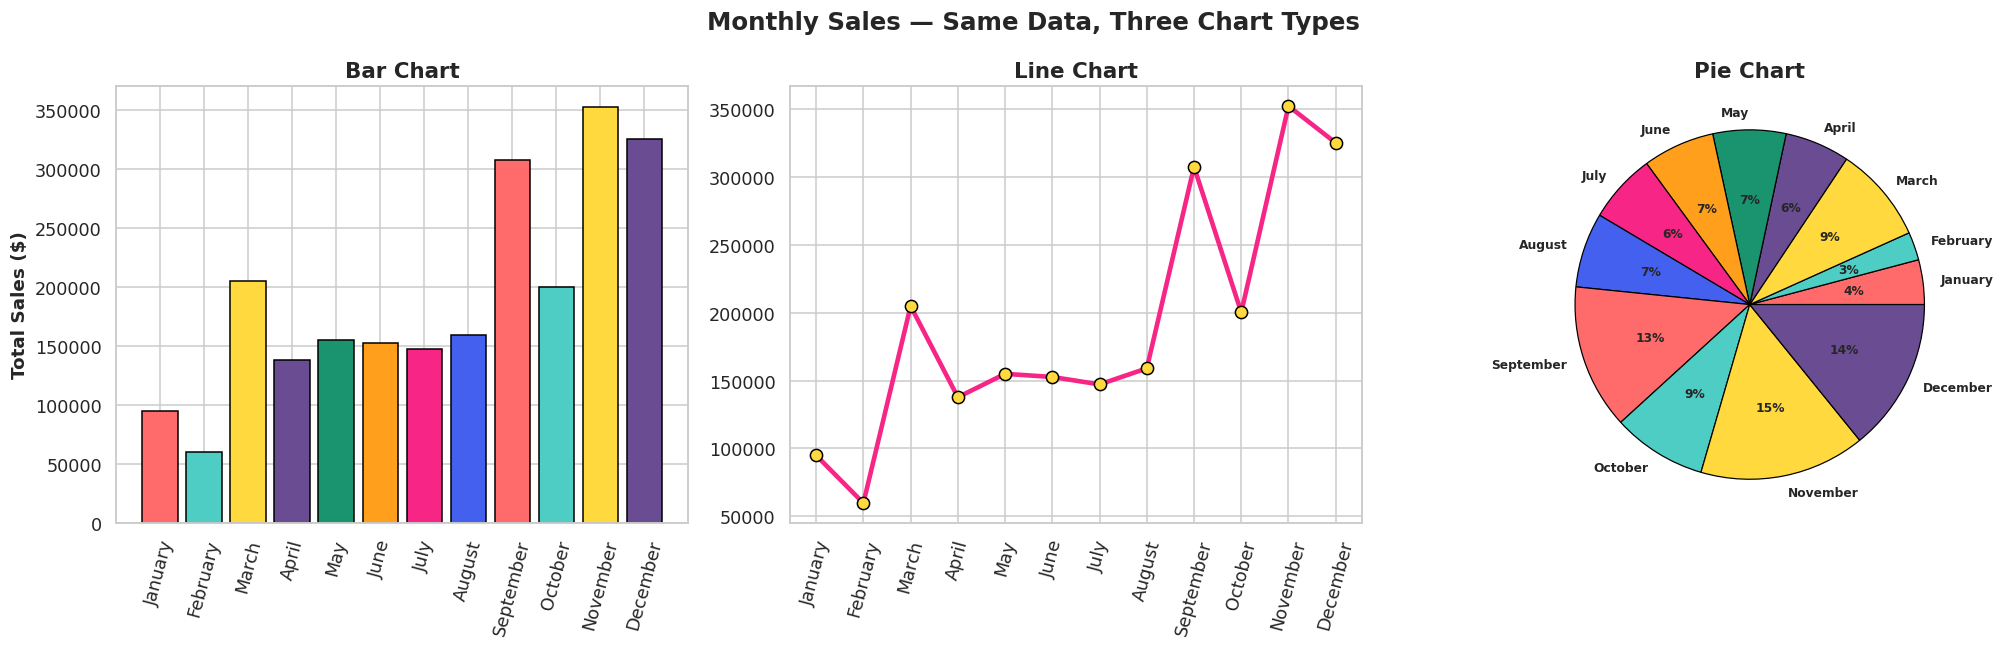

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6))

axes[0].bar(monthly_sales_cal.index, monthly_sales_cal.values, color=vibrant * 2, edgecolor='black', linewidth=1)
axes[0].set_title('Bar Chart', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Sales ($)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=75)

axes[1].plot(monthly_sales_cal.index, monthly_sales_cal.values, color='#F72585', marker='o', markersize=8, linewidth=3, markerfacecolor='#FFD93D', markeredgecolor='black')
axes[1].set_title('Line Chart', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=75)

axes[2].pie(monthly_sales_cal.values, labels=monthly_sales_cal.index, colors=vibrant * 2, autopct='%1.0f%%', textprops={'fontsize': 8, 'fontweight': 'bold'}, wedgeprops={'edgecolor': 'black', 'linewidth': 0.8})
axes[2].set_title('Pie Chart', fontsize=14, fontweight='bold')

plt.suptitle('Monthly Sales — Same Data, Three Chart Types', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("The line chart shows the trend best because position along a continuous axis lets the eye follow the month-to-month rise and fall directly. The pie chart hides the trend completely: it has no sense of order or sequence, so twelve similarly-sized wedges just look like a shuffled category breakdown with no visible direction of change.")


## Task 2: Effectiveness & Appropriateness

A bar chart fits because it uses length/position, the most accurate channels, to make precise magnitude differences between 5 named categories obvious; a pie chart would force viewers to compare wedge angles, which humans judge far less accurately than bar length.


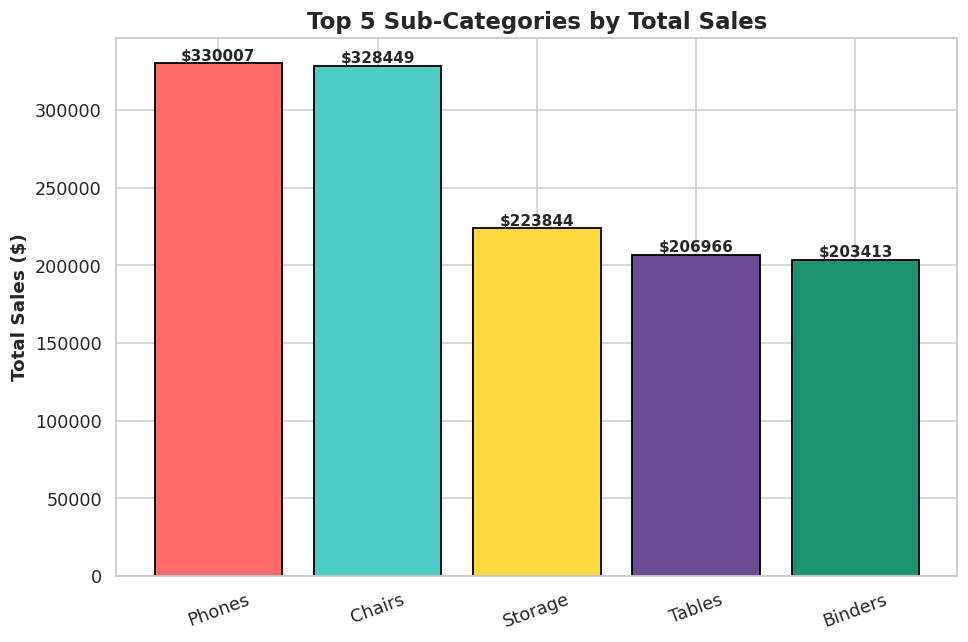

In [3]:
top5_subcat = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(5)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(top5_subcat.index, top5_subcat.values, color=vibrant, edgecolor='black', linewidth=1.2)
ax.bar_label(bars, fmt='$%.0f', fontsize=10, fontweight='bold')
ax.set_title('Top 5 Sub-Categories by Total Sales', fontsize=15, fontweight='bold')
ax.set_ylabel('Total Sales ($)', fontsize=12, fontweight='bold')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print("A bar chart fits because it uses length/position, the most accurate channels, to make precise magnitude differences between 5 named categories obvious; a pie chart would force viewers to compare wedge angles, which humans judge far less accurately than bar length.")


A line chart fits because the ordered, continuous date axis lets a connected line show direction and rate of change across many months at once; a bar chart with this many time points would turn into cluttered, hard-to-compare stripes with no clear directional read.


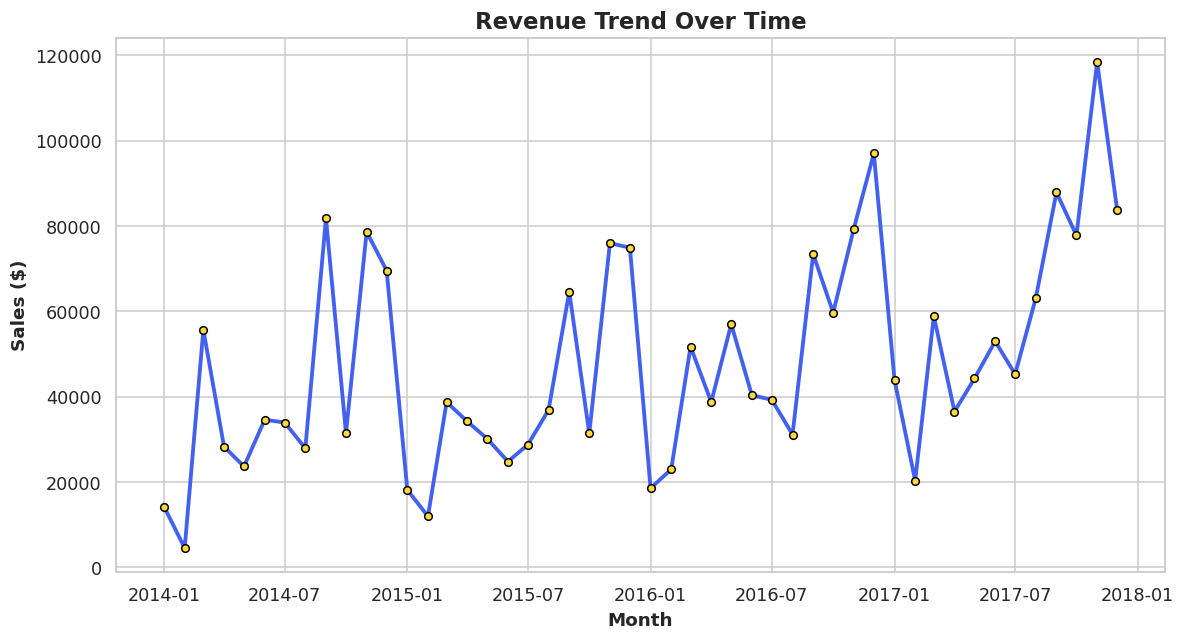

In [4]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(monthly_ts.index, monthly_ts['Sales'], color='#4361EE', marker='o', markersize=5, linewidth=2.5, markerfacecolor='#FFD93D', markeredgecolor='black')
ax.set_title('Revenue Trend Over Time', fontsize=15, fontweight='bold')
ax.set_ylabel('Sales ($)', fontsize=12, fontweight='bold')
ax.set_xlabel('Month', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("A line chart fits because the ordered, continuous date axis lets a connected line show direction and rate of change across many months at once; a bar chart with this many time points would turn into cluttered, hard-to-compare stripes with no clear directional read.")


A histogram fits because binning the raw sales values and using bar height to show frequency directly reveals the shape of the distribution (here, a strong right skew); a bar-of-averages would collapse this into one number and hide the shape and spread entirely.


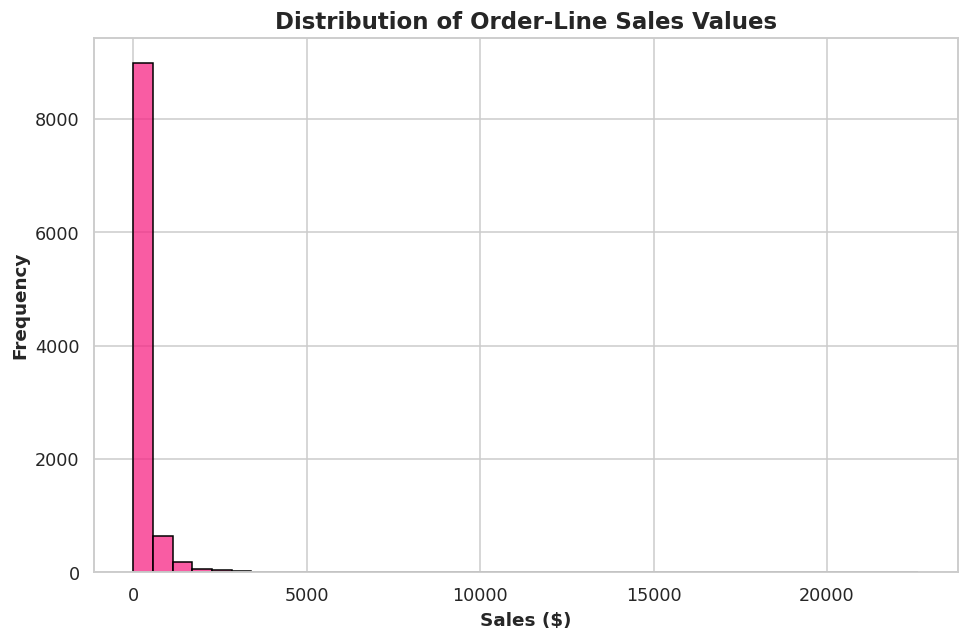

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.histplot(df['Sales'], bins=40, color='#F72585', edgecolor='black', ax=ax)
ax.set_title('Distribution of Order-Line Sales Values', fontsize=15, fontweight='bold')
ax.set_xlabel('Sales ($)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("A histogram fits because binning the raw sales values and using bar height to show frequency directly reveals the shape of the distribution (here, a strong right skew); a bar-of-averages would collapse this into one number and hide the shape and spread entirely.")


A scatter plot fits because each point uses position on two axes at once, the strongest possible encoding for showing how two numeric variables relate; a line chart would be misleading here since discount and profit are not an ordered time sequence, so connecting the raw points implies a trend that isn't real.


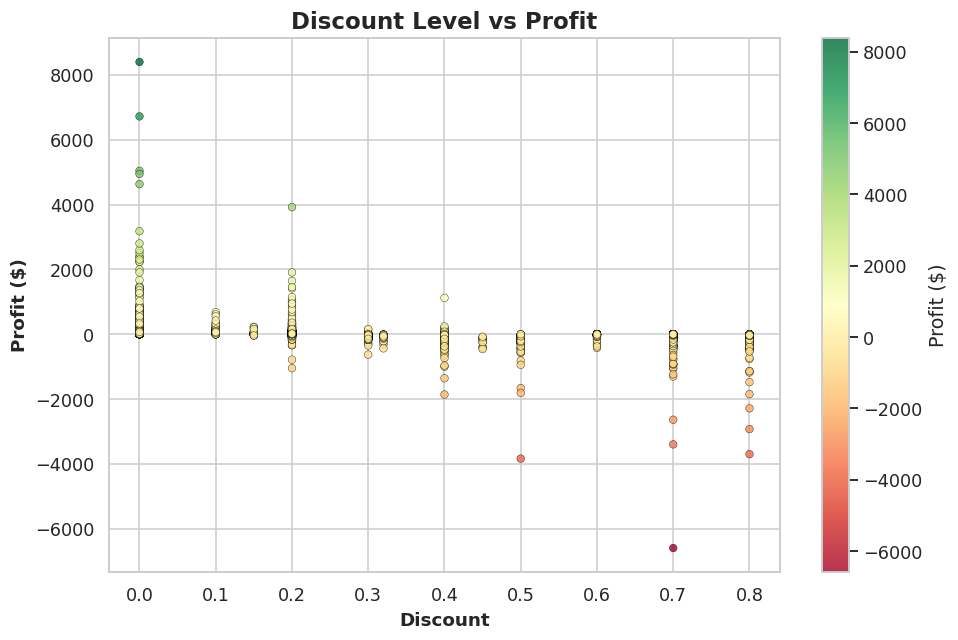

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(df['Discount'], df['Profit'], c=df['Profit'], cmap='RdYlGn', s=25, edgecolor='black', linewidth=0.3, alpha=0.8)
plt.colorbar(sc, label='Profit ($)')
ax.set_title('Discount Level vs Profit', fontsize=15, fontweight='bold')
ax.set_xlabel('Discount', fontsize=12, fontweight='bold')
ax.set_ylabel('Profit ($)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("A scatter plot fits because each point uses position on two axes at once, the strongest possible encoding for showing how two numeric variables relate; a line chart would be misleading here since discount and profit are not an ordered time sequence, so connecting the raw points implies a trend that isn't real.")


## Task 3: Color Selection

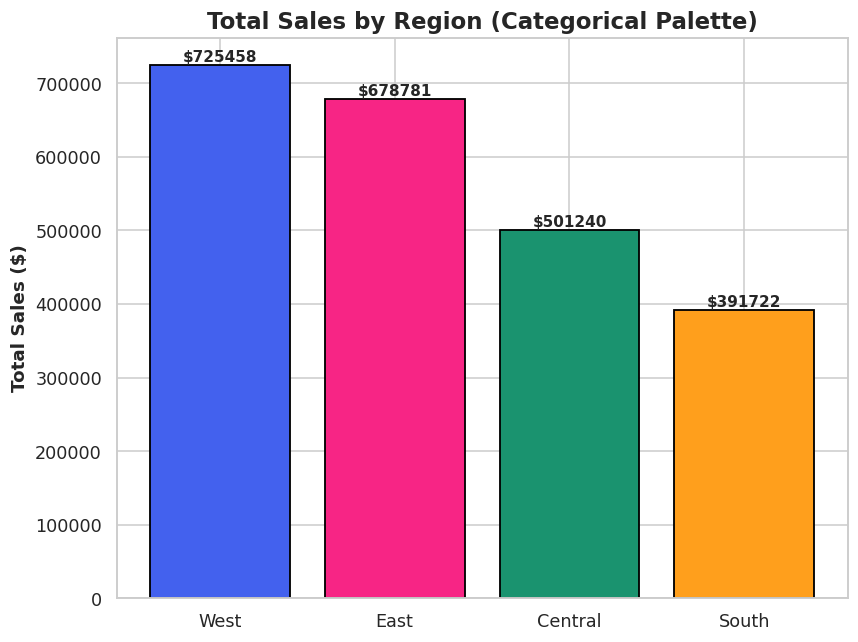

In [7]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
categorical_palette = ['#4361EE', '#F72585', '#1A936F', '#FF9F1C']

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(region_sales.index, region_sales.values, color=categorical_palette, edgecolor='black', linewidth=1.2)
ax.bar_label(bars, fmt='$%.0f', fontsize=10, fontweight='bold')
ax.set_title('Total Sales by Region (Categorical Palette)', fontsize=15, fontweight='bold')
ax.set_ylabel('Total Sales ($)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


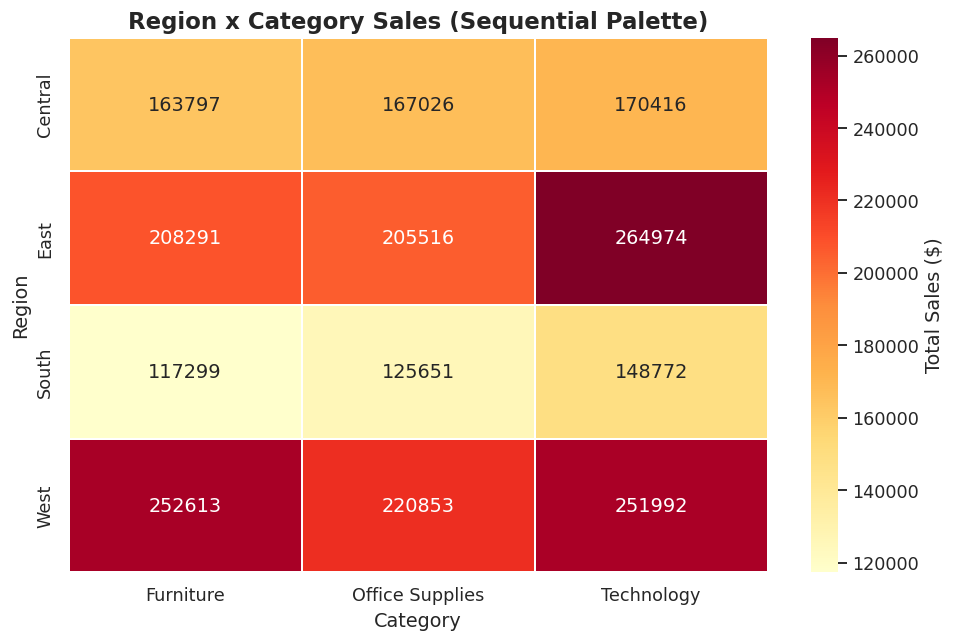

In [8]:
region_cat_pivot = df.pivot_table(index='Region', columns='Category', values='Sales', aggfunc='sum')

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(region_cat_pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=1, linecolor='white', cbar_kws={'label': 'Total Sales ($)'}, ax=ax)
ax.set_title('Region x Category Sales (Sequential Palette)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


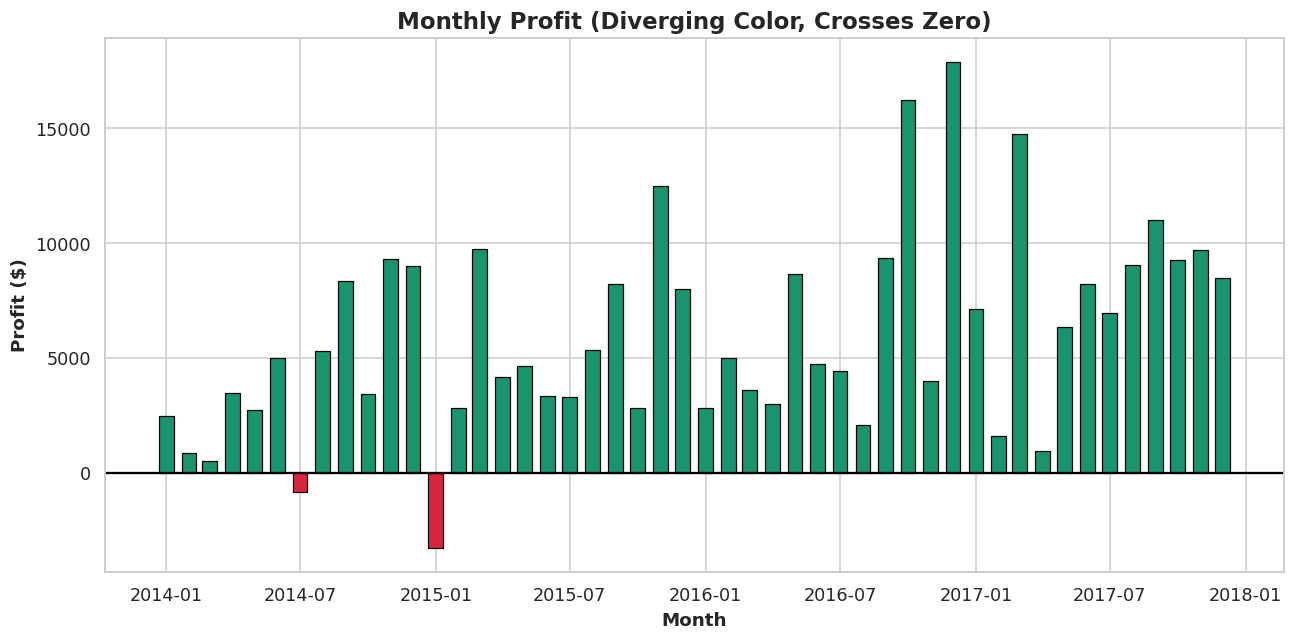

In [9]:
monthly_profit = monthly_ts['Profit']
colors_div = ['#D7263D' if v < 0 else '#1A936F' for v in monthly_profit.values]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(monthly_profit.index, monthly_profit.values, color=colors_div, edgecolor='black', linewidth=0.8, width=20)
ax.axhline(0, color='black', linewidth=1.5)
ax.set_title('Monthly Profit (Diverging Color, Crosses Zero)', fontsize=15, fontweight='bold')
ax.set_ylabel('Profit ($)', fontsize=12, fontweight='bold')
ax.set_xlabel('Month', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## Task 4: Accessibility

In [10]:
def relative_luminance(rgb):
    def channel(c):
        c = c / 255
        return c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4
    r, g, b = rgb
    return 0.2126 * channel(r) + 0.7152 * channel(g) + 0.0722 * channel(b)

def contrast_ratio(rgb1, rgb2):
    l1 = relative_luminance(rgb1)
    l2 = relative_luminance(rgb2)
    lighter, darker = max(l1, l2), min(l1, l2)
    return (lighter + 0.05) / (darker + 0.05)

hex_colors = {'Blue': '#4361EE', 'Pink': '#F72585', 'Green': '#1A936F', 'Orange': '#FF9F1C'}
def hex_to_rgb(h):
    h = h.lstrip('#')
    return tuple(int(h[i:i+2], 16) for i in (0, 2, 4))

white = (255, 255, 255)
for name, hexcode in hex_colors.items():
    ratio = contrast_ratio(hex_to_rgb(hexcode), white)
    status = 'PASS' if ratio >= 4.5 else 'FAIL'
    print(f"{name} vs white background: {ratio:.2f}:1 -> {status} AA")


Blue vs white background: 5.02:1 -> PASS AA
Pink vs white background: 3.78:1 -> FAIL AA
Green vs white background: 3.86:1 -> FAIL AA
Orange vs white background: 2.05:1 -> FAIL AA


Alt text: Horizontal bar chart of total profit by product sub-category, ranging from a loss in Tables to the highest gain in Copiers; loss bars are shown in hatched blue, gain bars in solid orange, so the distinction remains visible under red-green color blindness.


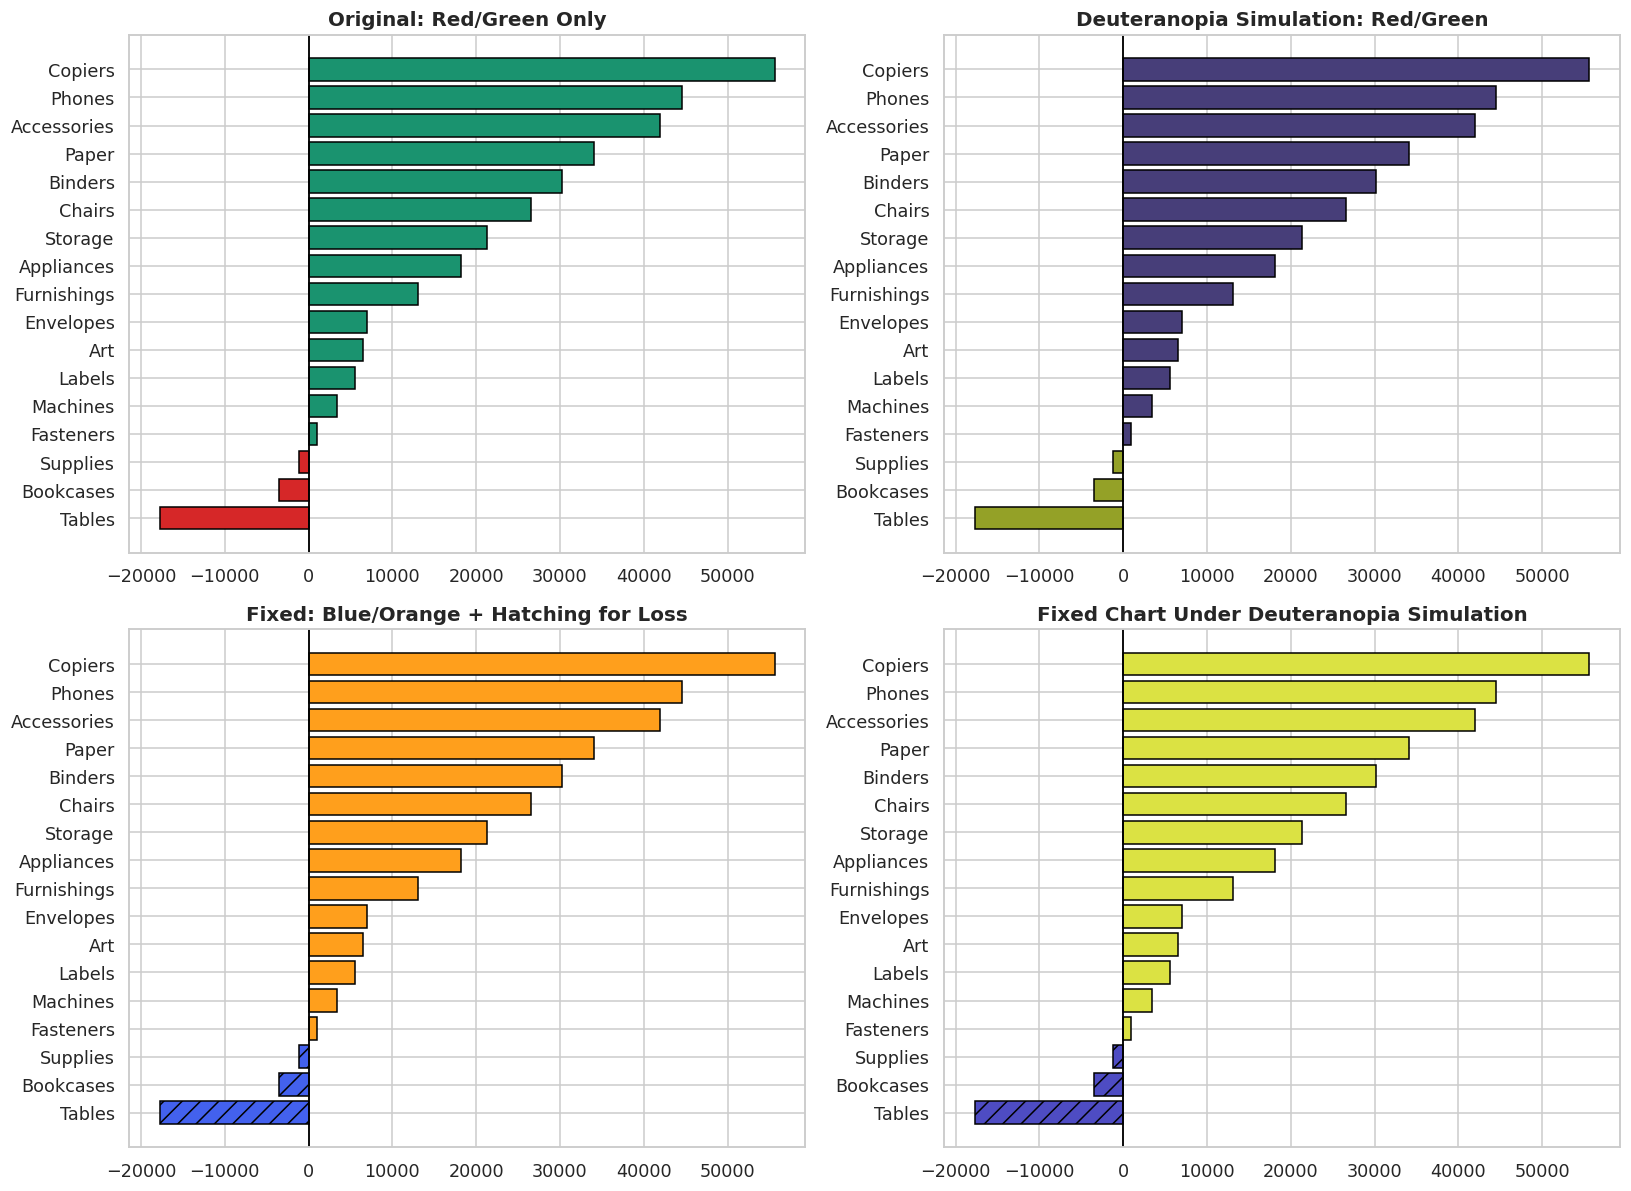

In [11]:
profit_by_subcat = df.groupby('Sub-Category')['Profit'].sum().sort_values()

def simulate_deuteranopia(rgb):
    m = np.array([[0.625, 0.375, 0.0], [0.7, 0.3, 0.0], [0.0, 0.3, 0.7]])
    return tuple(np.clip(m @ np.array(rgb), 0, 255).astype(int))

red = (214, 39, 40)
green = (26, 147, 111)
red_cb = simulate_deuteranopia(red)
green_cb = simulate_deuteranopia(green)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
colors_rg = [(214/255, 39/255, 40/255) if v < 0 else (26/255, 147/255, 111/255) for v in profit_by_subcat.values]
axes[0, 0].barh(profit_by_subcat.index, profit_by_subcat.values, color=colors_rg, edgecolor='black')
axes[0, 0].axvline(0, color='black', linewidth=1.2)
axes[0, 0].set_title('Original: Red/Green Only', fontsize=13, fontweight='bold')

colors_rg_cb = [tuple(c/255 for c in red_cb) if v < 0 else tuple(c/255 for c in green_cb) for v in profit_by_subcat.values]
axes[0, 1].barh(profit_by_subcat.index, profit_by_subcat.values, color=colors_rg_cb, edgecolor='black')
axes[0, 1].axvline(0, color='black', linewidth=1.2)
axes[0, 1].set_title('Deuteranopia Simulation: Red/Green', fontsize=13, fontweight='bold')

blue = '#4361EE'
orange = '#FF9F1C'
colors_fixed = [blue if v < 0 else orange for v in profit_by_subcat.values]
bars_fixed = axes[1, 0].barh(profit_by_subcat.index, profit_by_subcat.values, color=colors_fixed, edgecolor='black')
for bar, v in zip(bars_fixed, profit_by_subcat.values):
    if v < 0:
        bar.set_hatch('//')
axes[1, 0].axvline(0, color='black', linewidth=1.2)
axes[1, 0].set_title('Fixed: Blue/Orange + Hatching for Loss', fontsize=13, fontweight='bold')

blue_cb = simulate_deuteranopia(hex_to_rgb(blue))
orange_cb = simulate_deuteranopia(hex_to_rgb(orange))
colors_fixed_cb = [tuple(c/255 for c in blue_cb) if v < 0 else tuple(c/255 for c in orange_cb) for v in profit_by_subcat.values]
bars_fixed_cb = axes[1, 1].barh(profit_by_subcat.index, profit_by_subcat.values, color=colors_fixed_cb, edgecolor='black')
for bar, v in zip(bars_fixed_cb, profit_by_subcat.values):
    if v < 0:
        bar.set_hatch('//')
axes[1, 1].axvline(0, color='black', linewidth=1.2)
axes[1, 1].set_title('Fixed Chart Under Deuteranopia Simulation', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("Alt text: Horizontal bar chart of total profit by product sub-category, ranging from a loss in Tables to the highest gain in Copiers; loss bars are shown in hatched blue, gain bars in solid orange, so the distinction remains visible under red-green color blindness.")


## Task 5: Misleading Visualizations — 3 Techniques

Caption: Truncated y-axis on region sales — starting the axis near the minimum value visually inflates small percentage differences between regions into what looks like a 5-10x gap.


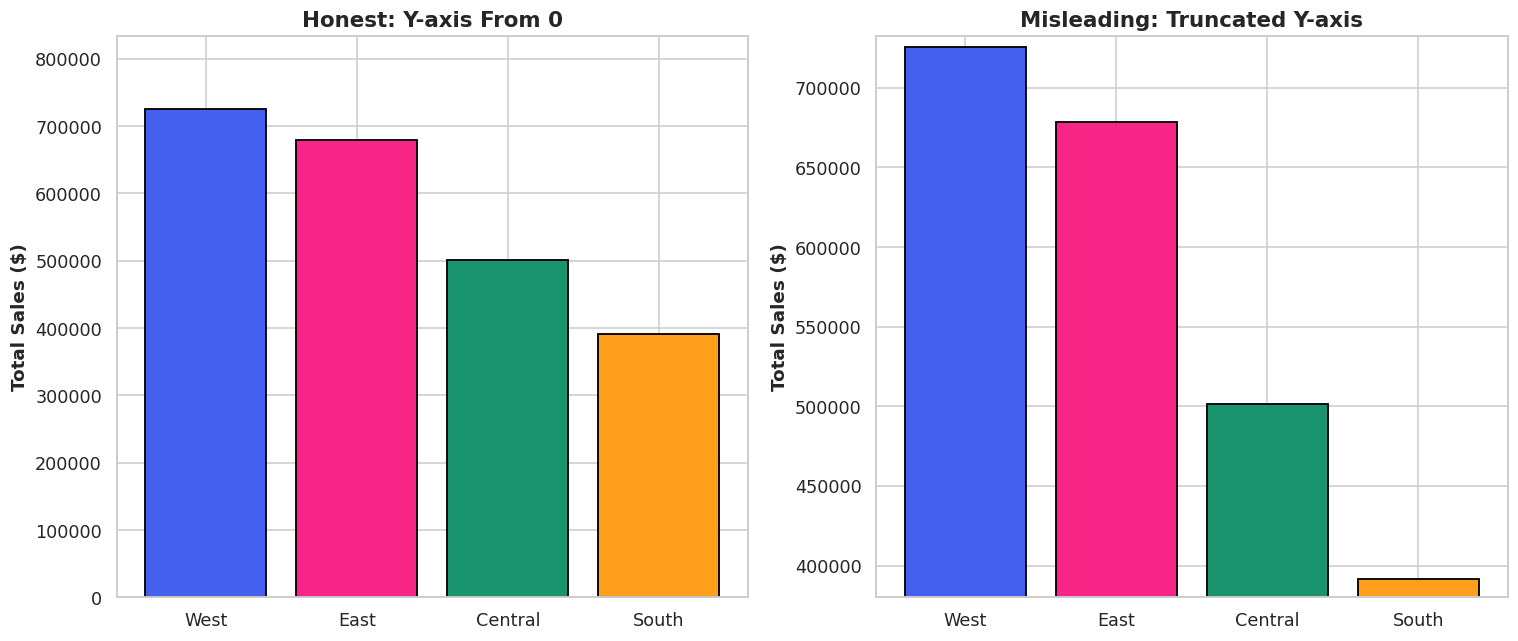

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(region_sales.index, region_sales.values, color=categorical_palette, edgecolor='black', linewidth=1.2)
axes[0].set_ylim(0, region_sales.max() * 1.15)
axes[0].set_title('Honest: Y-axis From 0', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Sales ($)', fontsize=12, fontweight='bold')

axes[1].bar(region_sales.index, region_sales.values, color=categorical_palette, edgecolor='black', linewidth=1.2)
axes[1].set_ylim(region_sales.min() * 0.97, region_sales.max() * 1.01)
axes[1].set_title('Misleading: Truncated Y-axis', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Total Sales ($)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()
print("Caption: Truncated y-axis on region sales — starting the axis near the minimum value visually inflates small percentage differences between regions into what looks like a 5-10x gap.")


Caption: Dual-axis overlay of Sales and Quantity — two independently-scaled axes are stretched so the lines visually track together, implying a tight correlation that the raw numbers don't actually support.


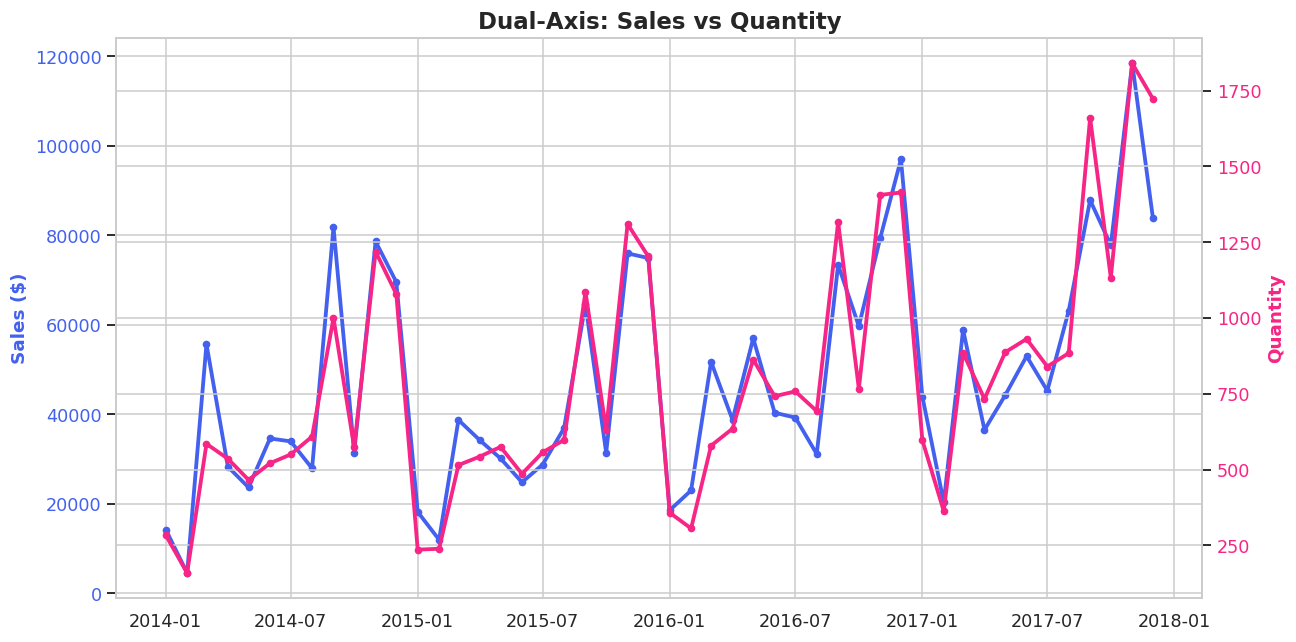

In [13]:
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(monthly_ts.index, monthly_ts['Sales'], color='#4361EE', linewidth=2.5, marker='o', markersize=4)
ax1.set_ylabel('Sales ($)', color='#4361EE', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#4361EE')

ax2 = ax1.twinx()
ax2.plot(monthly_ts.index, monthly_ts['Quantity'], color='#F72585', linewidth=2.5, marker='o', markersize=4)
ax2.set_ylabel('Quantity', color='#F72585', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#F72585')

ax1.set_title('Dual-Axis: Sales vs Quantity', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("Caption: Dual-axis overlay of Sales and Quantity — two independently-scaled axes are stretched so the lines visually track together, implying a tight correlation that the raw numbers don't actually support.")


Caption: Cherry-picked date window on monthly profit — zooming into a single declining stretch hides the surrounding recovery visible in the full timeline, making an isolated dip look like an ongoing downward trend.


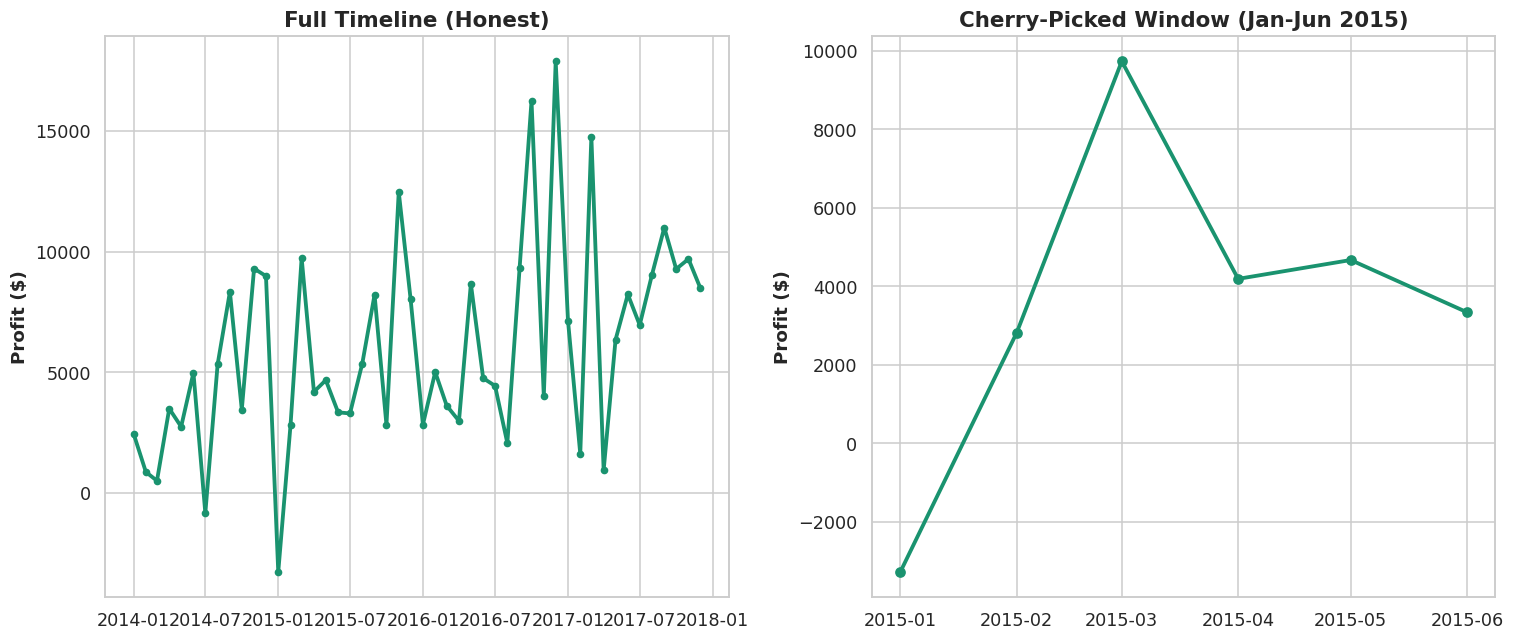

In [14]:
window = monthly_ts.loc['2015-01-01':'2015-06-01']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].plot(monthly_ts.index, monthly_ts['Profit'], color='#1A936F', linewidth=2.5, marker='o', markersize=4)
axes[0].set_title('Full Timeline (Honest)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Profit ($)', fontsize=12, fontweight='bold')

axes[1].plot(window.index, window['Profit'], color='#1A936F', linewidth=2.5, marker='o', markersize=6)
axes[1].set_title('Cherry-Picked Window (Jan-Jun 2015)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Profit ($)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()
print("Caption: Cherry-picked date window on monthly profit — zooming into a single declining stretch hides the surrounding recovery visible in the full timeline, making an isolated dip look like an ongoing downward trend.")


## Task 6: Real Analytical Question — Is Discounting Hurting Profit?

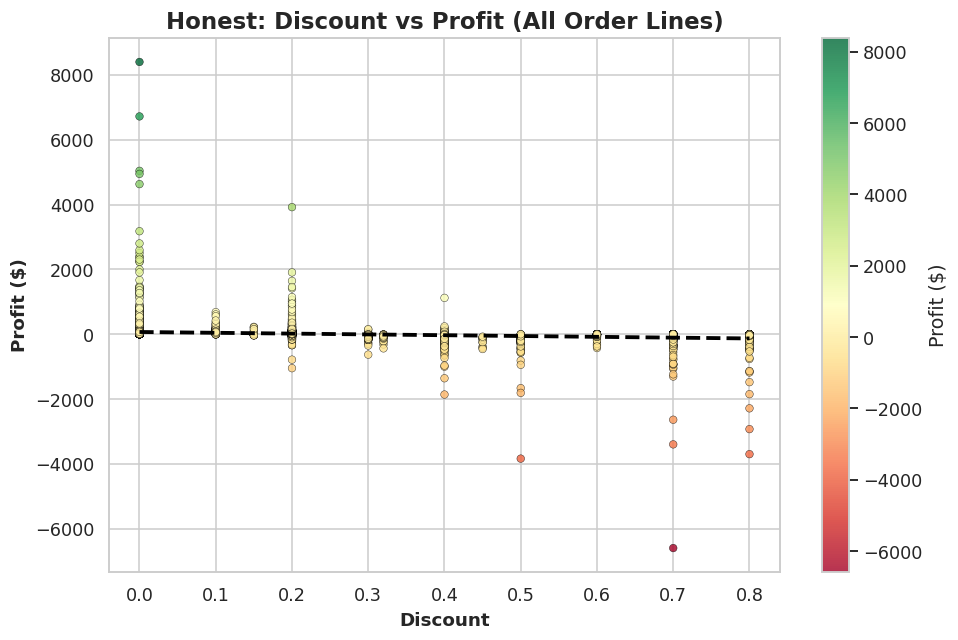

In [15]:
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(df['Discount'], df['Profit'], c=df['Profit'], cmap='RdYlGn', s=25, edgecolor='black', linewidth=0.3, alpha=0.8)
z = np.polyfit(df['Discount'], df['Profit'], 1)
xline = np.linspace(df['Discount'].min(), df['Discount'].max(), 100)
ax.plot(xline, np.polyval(z, xline), color='black', linewidth=2.5, linestyle='--')
plt.colorbar(sc, label='Profit ($)')
ax.set_title('Honest: Discount vs Profit (All Order Lines)', fontsize=15, fontweight='bold')
ax.set_xlabel('Discount', fontsize=12, fontweight='bold')
ax.set_ylabel('Profit ($)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


Correlation between discount and profit (full data): -0.219
Justification: The honest chart is a scatter plot with a fitted trend line since discount and profit are both raw numeric variables and a scatter is the strongest encoding for showing their relationship across all order lines; color follows a diverging red-to-green colormap centered on the natural zero-profit midpoint, which matches the sequential-vs-diverging guidance since losses and gains are meaningfully different directions, not just different magnitudes. The misleading version restricts the data to only low discounts and truncates the y-axis, which erases the steep negative slope visible at higher discounts and makes discounting look nearly harmless. Accessibility check: the diverging red/green scatter fails the 'never encode meaning with red vs green alone' rule from Section 3, so a colorblind-safe version should switch to a blue-to-orange diverging colormap instead.


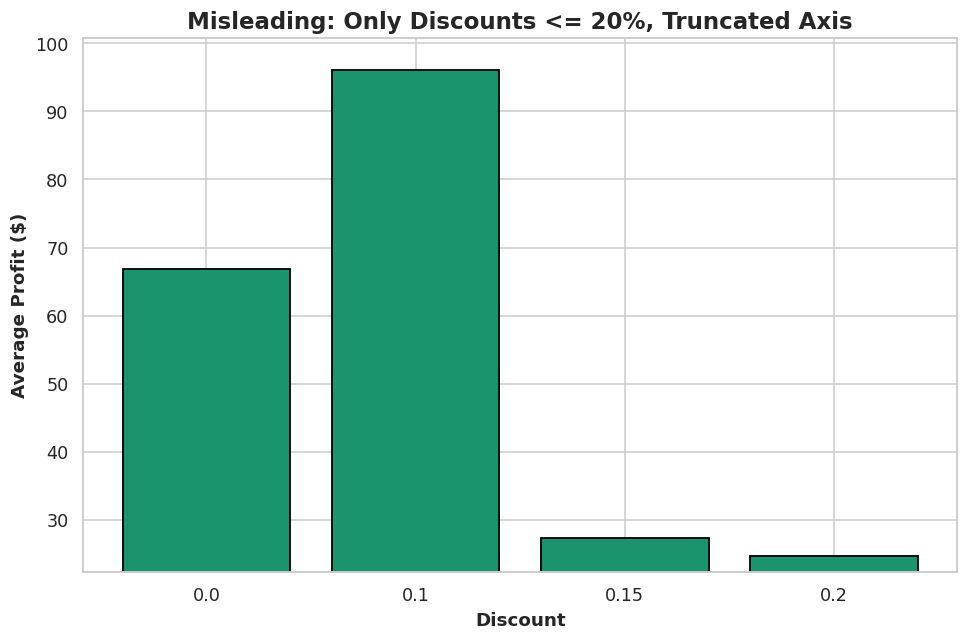

In [16]:
low_discount = df[df['Discount'] <= 0.2]
avg_profit_low = low_discount.groupby('Discount')['Profit'].mean()

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(avg_profit_low.index.astype(str), avg_profit_low.values, color='#1A936F', edgecolor='black', linewidth=1.2)
ax.set_ylim(avg_profit_low.min() * 0.9, avg_profit_low.max() * 1.05)
ax.set_title('Misleading: Only Discounts <= 20%, Truncated Axis', fontsize=15, fontweight='bold')
ax.set_xlabel('Discount', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Profit ($)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

corr = df['Discount'].corr(df['Profit'])
print(f"Correlation between discount and profit (full data): {corr:.3f}")
print("Justification: The honest chart is a scatter plot with a fitted trend line since discount and profit are both raw numeric variables and a scatter is the strongest encoding for showing their relationship across all order lines; color follows a diverging red-to-green colormap centered on the natural zero-profit midpoint, which matches the sequential-vs-diverging guidance since losses and gains are meaningfully different directions, not just different magnitudes. The misleading version restricts the data to only low discounts and truncates the y-axis, which erases the steep negative slope visible at higher discounts and makes discounting look nearly harmless. Accessibility check: the diverging red/green scatter fails the 'never encode meaning with red vs green alone' rule from Section 3, so a colorblind-safe version should switch to a blue-to-orange diverging colormap instead.")
